In [233]:
import torch
import torch.nn.functional as F
import string
char2index = {s:i for i,s in enumerate(string.ascii_lowercase)}
print(char2index)

{'a': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4, 'f': 5, 'g': 6, 'h': 7, 'i': 8, 'j': 9, 'k': 10, 'l': 11, 'm': 12, 'n': 13, 'o': 14, 'p': 15, 'q': 16, 'r': 17, 's': 18, 't': 19, 'u': 20, 'v': 21, 'w': 22, 'x': 23, 'y': 24, 'z': 25}


In [234]:
example = 'love'
idx = []
for char in example:
    idx.append(char2index[char])

idx = torch.tensor(idx)
print(idx)

tensor([11, 14, 21,  4])


In [235]:
# 使用 one- hot, 将文本转换为二维张量
num_claz = len(char2index)
num_claz

26

In [236]:
x = F.one_hot(idx, num_claz).float()
print(x, x.shape)

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0.]]) torch.Size([4, 26])


In [237]:
dims =5  # 选择一个固定的、合适的嵌入维度（如16、32、128等）
w = torch.randn(num_claz, dims)
print(w, w.shape)

tensor([[ 0.2781, -0.2066,  0.0061,  2.2744, -1.1781],
        [ 0.7382, -1.5514,  1.3733,  0.4012, -0.4609],
        [-0.0664,  1.7666, -1.5193, -1.1042,  1.2713],
        [ 0.0937,  1.1992, -0.3121, -1.0789, -0.2401],
        [-0.3200, -1.0543, -0.6145,  1.8502,  0.2356],
        [ 0.4559,  0.5359,  0.6857, -0.7095, -0.0679],
        [ 1.2324,  0.5278, -1.3090, -0.5538,  1.0898],
        [ 0.6420,  0.5838, -0.8256,  1.0579, -2.0551],
        [-0.1616,  0.4774, -0.6330, -0.2815, -0.2989],
        [-1.3060,  2.3707,  2.4696, -1.9825,  0.0986],
        [-1.4353,  0.0547,  0.4130,  0.4311,  0.9513],
        [ 1.8950, -0.3015,  1.5791,  0.3128, -0.7041],
        [-0.4010, -0.2357, -1.2650,  2.6279,  0.6836],
        [ 0.2908,  1.1733, -1.5955,  0.3454, -0.6937],
        [-0.1595, -0.8831,  1.3014, -0.9533,  0.2090],
        [-1.3138,  0.5495, -0.1719, -0.1500,  1.7226],
        [-0.2539, -1.3533, -0.8531,  0.0694, -0.6225],
        [ 0.8976,  1.3932,  0.0364, -0.4834, -0.0386],
        [-

In [238]:
print(torch.matmul(x, w))

tensor([[ 1.8950, -0.3015,  1.5791,  0.3128, -0.7041],
        [-0.1595, -0.8831,  1.3014, -0.9533,  0.2090],
        [-0.2969,  0.5898,  1.2572, -1.4390,  1.1961],
        [-0.3200, -1.0543, -0.6145,  1.8502,  0.2356]])


In [239]:
# 简便语法 省略one-hot
print(w[idx],w[idx].shape)

tensor([[ 1.8950, -0.3015,  1.5791,  0.3128, -0.7041],
        [-0.1595, -0.8831,  1.3014, -0.9533,  0.2090],
        [-0.2969,  0.5898,  1.2572, -1.4390,  1.1961],
        [-0.3200, -1.0543, -0.6145,  1.8502,  0.2356]]) torch.Size([4, 5])


In [240]:
# 实现上面功能（文本嵌套层）
#文本嵌入 = 给每个词或句子分配一个独特的向量表示，让语义相近的词在向量空间中也相近。
class Embeding:
    def __init__(self, num_embeddings , embedding_dims):
        self.weight = torch.randn((num_embeddings, embedding_dims),requires_grad=True)

    def __call__(self, x):
        self.out = self.weight[x]
        return self.out

    def parameters(self):
        return self.weight

In [241]:
Em = Embeding(num_claz,dims)
print(Em(idx).shape)

torch.Size([4, 5])


In [242]:
x = torch.randint(0,num_claz,(20,10))
print(x.shape)

torch.Size([20, 10])


In [243]:
print(Em(x).shape) #20个文本，文本长度是10，每个文本有5个特征

torch.Size([20, 10, 5])


In [244]:
# 检查是否支持MPS
import torch
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("使用MPS！")
else:
    device = torch.device("cpu")
    print("使用CPU")

使用MPS！


In [245]:
import torch.optim as optim
from torch.utils.data import DataLoader
from datasets  import load_dataset
import matplotlib.pyplot as plt

# 使用通配符匹配所有分片
data_path = "/Users/hujinjia/PycharmProjects/JupyterProject/python/python/final/jsonl/train/*.jsonl.gz"
datasets = load_dataset('json', data_files=data_path)
datasets = datasets['train'].filter(lambda x: 'apache/spark' in x['repo'])

In [246]:
print(datasets[8]['original_string'])

def to_arrow_schema(schema):
    """ Convert a schema from Spark to Arrow
    """
    import pyarrow as pa
    fields = [pa.field(field.name, to_arrow_type(field.dataType), nullable=field.nullable)
              for field in schema]
    return pa.schema(fields)


In [247]:
class CharTokenizer:
    def __init__(self, data, begin_ind=0, end_ind=1):
        chars = sorted(list(set(''.join(data))))
        self.char2ind = {s: i+2 for i, s in enumerate(chars)} # 创建 {字符: 索引} 的映射。self.char2ind = {'a': 2, 'b': 3, 'c': 4}
        self.char2ind['<|b|>'] = begin_ind
        self.char2ind['<|e|>'] = end_ind
        self.ind2char = {v:k for k, v in self.char2ind.items()} # 创建从索引到字符的反向映射，便于解码。self.ind2chat = {0: '<|b|>', 1: '<|e|>', 2: 'a', 3: 'b', 4: 'c'}
        self.begin_ind = begin_ind
        self.end_ind = end_ind

    def encode(self,x):
        return [self.char2ind[i] for i in x]

    def decode(self,x):
        if isinstance(x,int):
            return self.ind2char[x]
        else:
            return [self.ind2char[i] for i in x]

In [248]:
#测试
data = ['class CharTokenizer: def __init__(self, data, begin_ind=0, end_ind=1): x']
chars = sorted(list(set(''.join(data))))
print(chars)
tokenizer = CharTokenizer(datasets['original_string'])
# test_str = 'def f(x)'
# re = tokenizer.encode(test_str)
# print(re)

[' ', '(', ')', ',', '0', '1', ':', '=', 'C', 'T', '_', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'n', 'o', 'r', 's', 't', 'x', 'z']


In [249]:
#print(tokenizer.decode(re))
#print(''.join(tokenizer.decode(re)))

In [250]:
def autoregressive_trans(text, tokenizer, context_length = 10):
    inputs, labels = [],[]
    bind = tokenizer.begin_ind
    eind = tokenizer.end_ind
    enc = tokenizer.encode(text)
    data = [bind]*context_length + enc + [eind]
    for i in range(len(data) - context_length):
        inputs.append(data[i:i+context_length])
        labels.append(data[i+context_length])
    return inputs, labels

In [251]:
inputs,labels = autoregressive_trans(test_str, tokenizer,3)
inputs,labels

([[0, 0, 0],
  [0, 0, 71],
  [0, 71, 72],
  [71, 72, 73],
  [72, 73, 3],
  [73, 3, 73],
  [3, 73, 11],
  [73, 11, 91],
  [11, 91, 12]],
 [71, 72, 73, 3, 73, 11, 91, 12, 1])

In [252]:
for a,b in zip(inputs, labels):
    print(f'{"".join(tokenizer.decode(a))} -> {"".join(tokenizer.decode(b))}')

<|b|><|b|><|b|> -> d
<|b|><|b|>d -> e
<|b|>de -> f
def ->  
ef  -> f
f f -> (
 f( -> x
f(x -> )
(x) -> <|e|>


In [253]:
for a,b in zip(inputs,labels):
    print(f'{a} -> {"".join(tokenizer.decode(b))}')

[0, 0, 0] -> d
[0, 0, 71] -> e
[0, 71, 72] -> f
[71, 72, 73] ->  
[72, 73, 3] -> f
[73, 3, 73] -> (
[3, 73, 11] -> x
[73, 11, 91] -> )
[11, 91, 12] -> <|e|>


In [254]:
def process(data, tokenizer):
    text = data['original_string']
    # for text is string
    if isinstance(text, str):
        inputs, labels = autoregressive_trans(text, tokenizer)
        return{'inputs': inputs, 'labels': labels}
    # for text is list[]
    inputs,labels = [],[]
    for t in text:
        i, l = autoregressive_trans(t, tokenizer)
        inputs = inputs + i
        labels = labels + l
    return{'inputs': inputs, 'labels': labels}

In [255]:
process(datasets[8],tokenizer)

{'inputs': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0, 0, 0, 0, 0, 71],
  [0, 0, 0, 0, 0, 0, 0, 0, 71, 72],
  [0, 0, 0, 0, 0, 0, 0, 71, 72, 73],
  [0, 0, 0, 0, 0, 0, 71, 72, 73, 3],
  [0, 0, 0, 0, 0, 71, 72, 73, 3, 87],
  [0, 0, 0, 0, 71, 72, 73, 3, 87, 82],
  [0, 0, 0, 71, 72, 73, 3, 87, 82, 66],
  [0, 0, 71, 72, 73, 3, 87, 82, 66, 68],
  [0, 71, 72, 73, 3, 87, 82, 66, 68, 85],
  [71, 72, 73, 3, 87, 82, 66, 68, 85, 85],
  [72, 73, 3, 87, 82, 66, 68, 85, 85, 82],
  [73, 3, 87, 82, 66, 68, 85, 85, 82, 90],
  [3, 87, 82, 66, 68, 85, 85, 82, 90, 66],
  [87, 82, 66, 68, 85, 85, 82, 90, 66, 86],
  [82, 66, 68, 85, 85, 82, 90, 66, 86, 70],
  [66, 68, 85, 85, 82, 90, 66, 86, 70, 75],
  [68, 85, 85, 82, 90, 66, 86, 70, 75, 72],
  [85, 85, 82, 90, 66, 86, 70, 75, 72, 80],
  [85, 82, 90, 66, 86, 70, 75, 72, 80, 68],
  [82, 90, 66, 86, 70, 75, 72, 80, 68, 11],
  [90, 66, 86, 70, 75, 72, 80, 68, 11, 86],
  [66, 86, 70, 75, 72, 80, 68, 11, 86, 70],
  [86, 70, 75, 72, 80, 68, 11, 86, 70, 75],

In [256]:
batch_size = 1000
learning_rate = 0.01
eval_iters = 10

In [257]:
# 数据分为训练和测试集
tokenized = datasets.train_test_split(test_size=0.1,seed=1042,shuffle=True)
print(tokenized.keys())
print(f"训练集大小: {len(tokenized['train'])}")
print(f"测试集大小: {len(tokenized['test'])}")

dict_keys(['train', 'test'])
训练集大小: 617
测试集大小: 69


In [258]:
# numpy 需要使用2.以下版本
f = lambda x: process(x, tokenizer)
tokenized = tokenized.map(f,batched=True, remove_columns = datasets.column_names) #功能：对数据集的每个样本应用处理函数
tokenized.set_format(type='torch',device = device)

In [259]:
train_loader = DataLoader(tokenized['train'], batch_size=batch_size, shuffle=True)
test_loader = DataLoader(tokenized['test'], batch_size=batch_size, shuffle=True)

In [260]:
next(iter(train_loader))

{'inputs': tensor([[80,  3, 80,  ..., 89, 76, 86],
         [ 3,  3,  3,  ..., 33, 33,  3],
         [41, 55, 92,  ..., 53, 50, 56],
         ...,
         [ 3,  3,  5,  ...,  3,  3,  3],
         [71, 29, 29,  ..., 17, 19,  2],
         [ 3,  3,  3,  ...,  3,  3,  3]], device='mps:0'),
 'labels': tensor([76, 86, 51, 76,  3, 74, 72,  3,  3,  3,  3, 72, 12, 82, 36, 29, 11,  3,
         16, 96, 68, 69,  3, 78, 81,  3, 76, 17, 70,  3,  3, 83, 85, 81, 11, 72,
          3, 76, 76, 51, 86, 11, 71, 81,  3, 71, 85, 87, 86, 37, 83, 54,  3, 81,
         68,  3, 16,  3,  3, 17, 75, 85,  3,  2,  3, 81,  3,  3, 68, 88, 76,  3,
         33, 73,  5,  3,  3, 71, 15, 68,  3, 85, 11, 76,  3, 68,  3, 72,  3,  2,
         87,  3, 69, 81, 68, 86,  3, 33, 79, 83,  3, 10, 81, 77,  3,  3, 33,  3,
         87, 83, 81, 20, 51,  3,  3, 82,  3,  2,  3, 86, 72,  3,  5, 87, 68,  5,
         10, 76, 86, 72, 39, 17, 73, 87,  3,  3, 77, 86,  3, 21,  3, 68, 72,  3,
         88, 11, 83, 76, 11, 86,  5, 11, 87,  3,  3, 7

In [261]:
# 使用pytorch里的文本嵌入Embeding
from torch import nn
class CharMLP(nn.Module):
    def __init__(self, vs):
        # vs 是字典的大小
        super().__init__()
        self.emb = nn.Embedding(vs, 30) # 使用30个特征来表示文本 。窗口长度是10
        self.hidden1 = nn.Linear(10*30, 200) #Embedding 后：shape是(10, 30)
        self.hidden2 = nn.Linear(200, 100)
        self.lm = nn.Linear(100, vs)

    def forward(self, x):
        # x:（B, 10)
        B = x.shape[0]
        emb = self.emb(x)  # (B, 10 , 30)
        h =  emb.view(B, -1) # (B,300)
        h = F.relu(self.hidden1(h)) # (B,200)
        h = F.relu(self.hidden2(h))  # (B,100)
        out = self.lm(h) ## (B, vs)
        return out

In [262]:
model = CharMLP(len(tokenizer.char2ind)).to(device)
model

CharMLP(
  (emb): Embedding(99, 30)
  (hidden1): Linear(in_features=300, out_features=200, bias=True)
  (hidden2): Linear(in_features=200, out_features=100, bias=True)
  (lm): Linear(in_features=100, out_features=99, bias=True)
)

In [263]:
def estimate_loss(model):
    re = {} #创建一个空字典，用于存储训练损失和测试损失,最终返回的结构：{'train': 0.123, 'test': 0.456}
    model.eval() #将训练模式切换为评估模式
    train_loss = _loss(model, train_loader)
    test_loss = _loss(model, test_loader)
    re['train'] = train_loss
    re['test'] = test_loss
    model.train()  #切换回训练模式
    return re

@torch.no_grad()
def _loss(model, data_loader):
    #计算模型在不同数据集下面的评估指标
    loss = []
    data_iter = iter(data_loader)
    # 随机使用多个批量数据来评估模型效果
    for k in range(eval_iters):
        data = next(data_iter, None) #如果没有数据，返回 None
        if data is None: # 如果当前迭代器没有数据了
            data_iter = iter(data_loader) # 重新创建迭代器
            data = next(data_iter, None) # 获取第一个 batch
        inputs, labels = data['inputs'], data['labels']
        logits = model(inputs)
        loss.append(F.cross_entropy(logits, labels).item()) # item() 将损失值(张量）转换为 Python 数字
    return torch.tensor(loss).mean().item()

estimate_loss(model)

{'train': 4.572558403015137, 'test': 4.571832180023193}

In [264]:
def train_model(model,optimizer,epochs=10):
    lossi = [] # 记录模型在训练集上的模型损失
    for epoch in range(epochs):
        for i, data in enumerate(train_loader, 0):
            inputs, labels = data['inputs'], data['labels']
            optimizer.zero_grad()
            logits = model(inputs)
            loss = F.cross_entropy(logits, labels)
            lossi.append(loss.item())
            loss.backward()
            optimizer.step()
        # 评估模型，并输出结果
        stats = estimate_loss(model)
        train_loss = f'train loss {stats['train']:.4f}'
        test_loss = f'test loss {stats['test']:.4f}'
        print(f'epoch {epoch:>2}: {train_loss}, {test_loss}')
    return lossi

In [265]:
@torch.no_grad()
def generate(model, context, tokenizer, max_new_tokens=300):
    """
        model: 训练好的语言模型
        context: 初始上下文，形状 (1, 10) - 1个样本，10个token
        tokenizer: 分词器，包含特殊标记索引
        max_new_tokens: 最大生成token数
    """
    out = []
    model.eval()
    for _ in range(max_new_tokens):
        logits = model(context)             # logits.shape: (1,99)
        probs = F.softmax(logits, dim=-1)   # softmax 将 logits 转换为概率分布所有概率之和为 1
        # 随机生成文本
        ix = torch.multinomial(probs, num_samples=1) # (1,1) 根据给定的概率分布 probs，随机采样 num_samples 个索引
        # 更新背景
        context = torch.concat((context[:,1:], ix), dim=1) #context[:,1:]: 去掉最左边的 token（滑动窗口), concat(...): 在右边拼接新生成的 token, 保持上下文长度不变（始终为10）
        out.append(ix.item())
        if out[-1] == tokenizer.end_ind: # 如果生成了结束标记,停止生成
            break
    model.train()
    return out

In [266]:
# 检查上面，生成未训练的文本
context = torch.zeros((1,10), dtype=torch.long, device = device)
print(''.join(tokenizer.decode(generate(model, context,tokenizer))))

3_bPTa|Jxq
x[jkm|I]QJ1}=n%fp[YHE[{\=YwX|{x@gZCK"[DS{ksC0(`iuS
|hzW
/%'Ag:`8=tXkrRJj,xC5%JSZA[\Wk\N)|^h<|e|>


In [267]:
# 训练模型
l = train_model(model, optim.Adam(model.parameters(), lr=learning_rate))

epoch  0: train loss 1.3541, test loss 1.4833
epoch  1: train loss 1.2599, test loss 1.3909
epoch  2: train loss 1.1899, test loss 1.3394
epoch  3: train loss 1.1599, test loss 1.3422
epoch  4: train loss 1.1175, test loss 1.3214
epoch  5: train loss 1.1509, test loss 1.3149
epoch  6: train loss 1.1084, test loss 1.2906
epoch  7: train loss 1.0799, test loss 1.2937
epoch  8: train loss 1.0869, test loss 1.2853
epoch  9: train loss 1.1099, test loss 1.2751


In [268]:
# 训练后的文本
context = torch.zeros((1,10), dtype=torch.long, device = device)
print(''.join(tokenizer.decode(generate(model, context,tokenizer))))

def sersepdateFormat=None):
            model in will numpy
        s
        sinated elprecess'.
        )
           puplabled all key is a supporteds, eed(path, old):
       for = self._jict(spartx.end(options), int arguments the new ata(self, data]
         RDD in Lrob= (Dgc._jvm. If a nrindiceJ


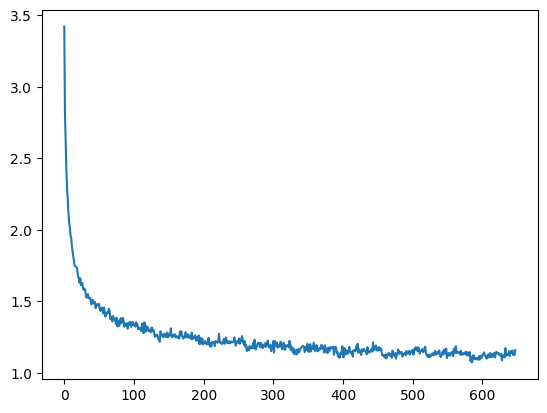

In [269]:
plt.plot(torch.tensor(l).view(-1,10).mean(dim =-1))